1. Data Processing:
- [X] Load and preprocess the data from the pickle file.
- [X] Flatten the hierarchical data structure into a suitable format for analysis.
- [X] Ensure data integrity and handle any missing or inconsistent data.
Exploratory Data Analysis.
- [X] Provide statistics about the dataset (e.g., number of syndromes, images per syndrome).
- [] Discuss any data imbalances or patterns observed.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
BASE_PATH = os.path.join("/", "content", "drive", "MyDrive", "projeto-apollo")
dataset_path = os.path.join(BASE_PATH, "mini_gm_public_v0.1.p")

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler,normalize
import tqdm

import random
import sys

In [4]:
with open(dataset_path, "rb") as dataset_file:
  dataset = np.load(dataset_file,allow_pickle=True)

In [ ]:
dir(dataset)

['__class__',
 '__class_getitem__',
 '__contains__',
 '__delattr__',
 '__delitem__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getitem__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__ior__',
 '__iter__',
 '__le__',
 '__len__',
 '__lt__',
 '__ne__',
 '__new__',
 '__or__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__reversed__',
 '__ror__',
 '__setattr__',
 '__setitem__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 'clear',
 'copy',
 'fromkeys',
 'get',
 'items',
 'keys',
 'pop',
 'popitem',
 'setdefault',
 'update',
 'values']

In [ ]:
dataset.keys()

dict_keys(['300000082', '300000080', '700018215', '100610883', '100180860', '300000018', '100192430', '300000034', '100610443', '300000007'])

In [ ]:
dataset['100180860']

{'2580': {'1722': array([ 9.13870454e-01,  1.13931274e+00,  5.48057735e-01, -1.75562072e+00,
          1.41784176e-01,  8.20718944e-01, -1.32763958e+00,  6.16614334e-02,
         -8.48063827e-01,  7.40095615e-01, -7.99556255e-01, -1.33356464e+00,
         -8.40341449e-01, -1.09386802e+00,  7.49288201e-01, -5.13042331e-01,
          1.07552254e+00, -1.14819396e+00,  6.52008414e-01, -7.67276362e-02,
         -8.88852179e-01, -1.46366918e+00,  7.15232015e-01,  1.28769290e+00,
         -1.13076496e+00,  1.91941118e+00, -2.85091460e-01, -3.35933894e-01,
          1.65785122e+00,  1.10053778e+00,  1.02900848e-01,  1.28895807e+00,
         -1.04884076e+00, -6.26661897e-01, -1.82413375e+00,  4.10212725e-01,
          1.86308876e-01, -7.89190352e-01,  1.98547518e+00,  1.77157640e+00,
         -5.13909757e-01,  1.10652018e+00,  8.30864832e-02,  7.79694140e-01,
         -1.07647419e+00,  1.30986035e-01,  1.18250453e+00, -1.11806169e-01,
         -6.81232452e-01,  3.36042568e-02,  1.81795645e+00, 

In [5]:
import pickle
with open(os.path.join(BASE_PATH, 'test.p'), 'wb') as file:
    pickle.dump({'100180860':dataset['100180860'], '300000080':dataset['300000080'], '300000034':dataset['300000034'], '100610443':dataset['100610443']}, file)


In [ ]:
#        syndrome   subject image
dataset['100180860']['2527']['1707']

array([ 1.73783672e+00,  1.79597557e+00,  2.46519852e+00, -2.31346250e+00,
        4.65286374e-01,  2.26594257e+00, -1.29198599e+00,  1.90543151e+00,
       -2.31313372e+00,  1.44681204e-02,  1.00822449e-01,  1.88793027e+00,
        5.76193333e-01, -1.66406357e+00, -4.73813713e-01,  1.02543902e+00,
        1.24669349e+00,  1.71210337e+00, -1.41598448e-01,  3.59250233e-02,
        1.10768652e+00, -2.31815910e+00,  8.57535243e-01, -5.68949342e-01,
        5.43757617e-01,  2.46998262e+00, -1.78561974e+00,  2.89397389e-01,
        6.43427849e-01,  6.40828848e-01, -1.57332218e+00,  2.26502395e+00,
       -2.37661648e+00, -6.75911188e-01, -4.51405972e-01,  6.36291564e-01,
        3.98648471e-01, -6.84287548e-01,  5.78109443e-01, -3.11325043e-01,
       -2.22184372e+00,  3.37247580e-01,  8.91017139e-01,  9.32840630e-02,
       -4.85441476e-01, -1.64386964e+00,  9.95222270e-01, -1.97543442e-01,
       -8.45401168e-01,  1.11812186e+00,  1.77591765e+00,  3.84282207e+00,
       -3.16908240e-01,  

In [6]:
mapping = pd.DataFrame(columns=("syndrome", "subject", "image", "image_size", "max_value", "min_value"))
mapping_save_path = os.path.join(BASE_PATH, "mapping.csv")

index = 0
for syndrome in dataset.keys():
  subjects = dataset[syndrome].keys()
  print("-"*20)
  print(f"Looking for Syndrome: `{syndrome}`")
  print(f"Total subjects: {len(subjects)}")

  amount_of_images = set()
  for subject in subjects:
    images = dataset[syndrome][subject].keys()
    amount_of_images.add(len(images))
    total_images_per_subject = 0

    for image_id in images:
      image = dataset[syndrome][subject][image_id]
      mapping.loc[index] = {"syndrome":syndrome, "subject":subject, "image":image_id, "image_size":len(image), "max_value":max(image), "min_value":min(image)}
      index += 1
      total_images_per_subject += 1
    print(f"Number of images for {subject} subject: {total_images_per_subject}")

  print(f"Overall amount of images: {list(amount_of_images)}")
print("#"*20)
print(f"Saving CSV in: {mapping_save_path} ...")
mapping.to_csv(mapping_save_path, index=False)
mapping.head()

--------------------
Looking for Syndrome: `300000082`
Total subjects: 83
Number of images for 595 subject: 1
Number of images for 2638 subject: 1
Number of images for 734490 subject: 1
Number of images for 2770 subject: 1
Number of images for 2642 subject: 1
Number of images for 739644 subject: 1
Number of images for 729196 subject: 1
Number of images for 1314 subject: 1
Number of images for 111 subject: 1
Number of images for 739643 subject: 1
Number of images for 739887 subject: 1
Number of images for 739886 subject: 1
Number of images for 739884 subject: 1
Number of images for 739883 subject: 1
Number of images for 735915 subject: 2
Number of images for 170 subject: 1
Number of images for 5902 subject: 1
Number of images for 794 subject: 1
Number of images for 2643 subject: 1
Number of images for 739860 subject: 1
Number of images for 738912 subject: 1
Number of images for 738913 subject: 1
Number of images for 735203 subject: 3
Number of images for 738911 subject: 1
Number of imag

,syndrome,subject,image,image_size,max_value,min_value
0,300000082,595,3543,320,4.576219,-3.935935
1,300000082,2638,1633,320,3.886438,-3.868779
2,300000082,734490,742992,320,2.186665,-2.335224
3,300000082,2770,1812,320,3.469533,-3.943067
4,300000082,2642,1801,320,3.716736,-4.187195


In [ ]:
import plotly.express as px

In [ ]:
data = mapping.groupby("syndrome").count()["image"].sort_values(ascending=True).reset_index()
data

,syndrome,image
0,700018215,64
1,100610883,65
2,100180860,67
3,300000018,74
4,100610443,89
5,300000082,98
6,300000007,115
7,100192430,136
8,300000080,198
9,300000034,210


In [ ]:


px.bar(
    data,
    x="syndrome",
    y="image",
    color="syndrome",
    title="Amount of Images per Syndrome"
)

data = mapping.groupby("syndrome").count()["image"].sort_values(ascending=True).reset_index()
data

In [ ]:
len(mapping[mapping["syndrome"] == mapping.syndrome[0]].subject.unique()),mapping.syndrome[0]

(83, '300000082')

In [ ]:
data = mapping.groupby("syndrome")["subject"].nunique().sort_values(ascending=True).reset_index()
px.bar(
    data,
    x="syndrome",
    y="subject",
    color="syndrome",
    title="Amount of Images per Syndrome"
)

In [ ]:
data1 = mapping.groupby("syndrome")["subject"].nunique().sort_values(ascending=True).reset_index()
data2 = mapping.groupby("syndrome").count()["image"].sort_values(ascending=True).reset_index()
df = pd.merge(data1, data2, on="syndrome")
px.line(
    df,
    x="syndrome",
    y=["subject", "image"],
    title="Amount of Images/Subjects per Syndrome",
    markers=True,
    labels={
        "value": "Amount",
        "variable": "Type",
        "syndrome": "Syndrome"
    }
)

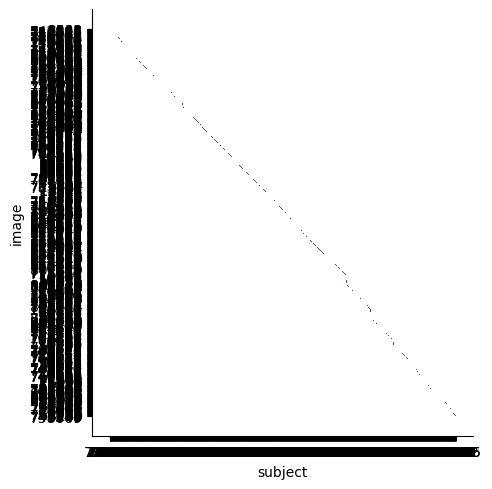

In [ ]:
sns.displot(data=mapping, x="subject", y="image")

In [ ]:
data = mapping.groupby(["syndrome", "subject"])["image"].count().sort_values(ascending=True).reset_index()
data.head()

,syndrome,subject,image
0,700018215,749337,1
1,700018215,749336,1
2,700018215,749335,1
3,700018215,749334,1
4,700018215,749333,1


In [ ]:
px.line(
    data,
    x="subject",
    y="image",
    color="syndrome",
    title="Amount of Images per Subject",
    labels={
        "image": "Amount of Images",
        "subject":"Subject",
        "syndrome":"Syndrome",
    },
    markers=True
)

In [ ]:
px.scatter(
    mapping,
    x="min_value",
    y="max_value",
    color="syndrome",
    hover_name="image",
    labels={
        "max_value":"Max Value",
        "min_value":"Min Value",
        "syndrome":"Syndrome"
    },
    title="Dispersion of Embeddings Min/Max Values"
    )

<Axes: xlabel='subject', ylabel='image'>

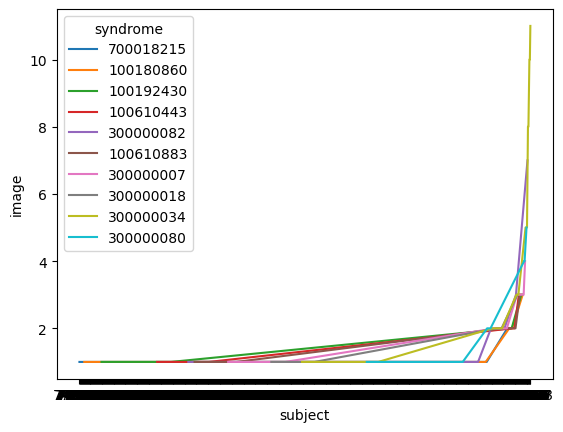

In [ ]:
sns.lineplot(data, x="subject", y="image", hue="syndrome")

In [ ]:
px.histogram(
    mapping,
    histfunc="sum",
    x="syndrome",
    y="image",
    color="syndrome",
    title="Amount of Images per Syndrome"
)

In [7]:
print(f"Dataset size: {sys.getsizeof(dataset)} bytes")
EACH_ARRAY_SIZE=320 # as described by the problem
total_images = mapping.shape[0]

print(f"Creating array of {(total_images,EACH_ARRAY_SIZE)}")
data_arr = np.ndarray((total_images,EACH_ARRAY_SIZE),dtype=np.float32)
data_arr_save_path = os.path.join(BASE_PATH, "data_arr.npy")

for i,row in mapping.iterrows():
  syndrome,subject,image_i = row["syndrome"],row["subject"],row["image"]
  image = dataset[syndrome][subject][image_i]

  if np.any(np.isnan(image)):
    print(f"Warning: NaN values found in image at index {i}")

  data_arr[i] = image

print(f"New array data size: {sys.getsizeof(data_arr)/(2**20):.2f} Mb")
print(f"New array dimensions: {data_arr.shape}")
print(f"Saving new array to file: {data_arr_save_path} ...")
np.save(data_arr_save_path,data_arr)

Dataset size: 272 bytes
Creating array of (1116, 320)
New array data size: 1.36 Mb
New array dimensions: (1116, 320)
Saving new array to file: /content/drive/MyDrive/projeto-apollo/data_arr.npy ...


In [ ]:
print("Statistics from our mapping data...")
mapping.describe()

Statistics from our mapping data...


,image_size,max_value,min_value
count,1116.0,1116.000000,1116.000000
mean,320.0,3.514369,-3.549105
std,0.0,0.632139,0.643378
min,320.0,1.807156,-7.986729
25%,320.0,3.064203,-3.889321
50%,320.0,3.433821,-3.481856
75%,320.0,3.898697,-3.111340
max,320.0,7.798529,-1.769748


In [ ]:
mapping.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1116 entries, 0 to 1115
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   syndrome    1116 non-null   object 
 1   subject     1116 non-null   object 
 2   image       1116 non-null   object 
 3   image_size  1116 non-null   int64  
 4   max_value   1116 non-null   float32
 5   min_value   1116 non-null   float32
dtypes: float32(2), int64(1), object(3)
memory usage: 52.3+ KB


In [ ]:
print(f"Different sizes: {mapping.image_size.unique()}")

Different sizes: [320]


In [ ]:
print("-=-Over all statistics-=-")
print(f"Number of syndromes: {len(mapping.syndrome.unique())}")
print(f"Number of subjects: {len(mapping.subject.unique())}")
print(f"Number of images: {len(mapping)}")

-=-Over all statistics-=-
Number of syndromes: 10
Number of subjects: 941
Number of images: 1116


---

# RUNNING TSNE

In [ ]:
plots_path = os.path.join(BASE_PATH, "plots")
os.makedirs(plots_path, exist_ok=True)


In [ ]:
tsne = TSNE(n_components=2, learning_rate='auto', init='pca', perplexity=30, n_jobs=4)
data_arr_norm = StandardScaler().fit_transform(data_arr)
reduced_embbedding = tsne.fit_transform(data_arr_norm)

In [ ]:
assert reduced_embbedding.shape[0] == data_arr_norm.shape[0] == data_arr.shape[0] == mapping.shape[0], "Invalid amount of rows!"
assert reduced_embbedding.shape[1] == 2, "Invalid amount of columns for reduced embedding!"
assert data_arr_norm.shape[1] == data_arr.shape[1], "Data array must have 320 images!"

In [ ]:
data_to_plot = pd.DataFrame(
    {
      "x":  reduced_embbedding[:,0],
      "y":  reduced_embbedding[:,1],
      "syndrome": mapping.syndrome.tolist(),
    },
    columns=("x", "y", "syndrome")
)

In [ ]:
MARKERS = [',', '.', 'o', 'v', '^', '<', '>', '8', 's', 'p', '*', 'h', 'H', 'D', 'd', 'P', 'X']  #https://github.com/mwaskom/seaborn/issues/1624
sampled_markers = random.sample(MARKERS,len(mapping.syndrome.unique()))
markers = {syndrome:sampled_markers[i] for i,syndrome in enumerate(mapping.syndrome.unique())}
print(f"Selected Markers: {markers}")

Selected Markers: {'300000082': '*', '300000080': 's', '700018215': ',', '100610883': 'P', '100180860': 'v', '300000018': '<', '100192430': 'X', '300000034': 'h', '100610443': '8', '300000007': '^'}


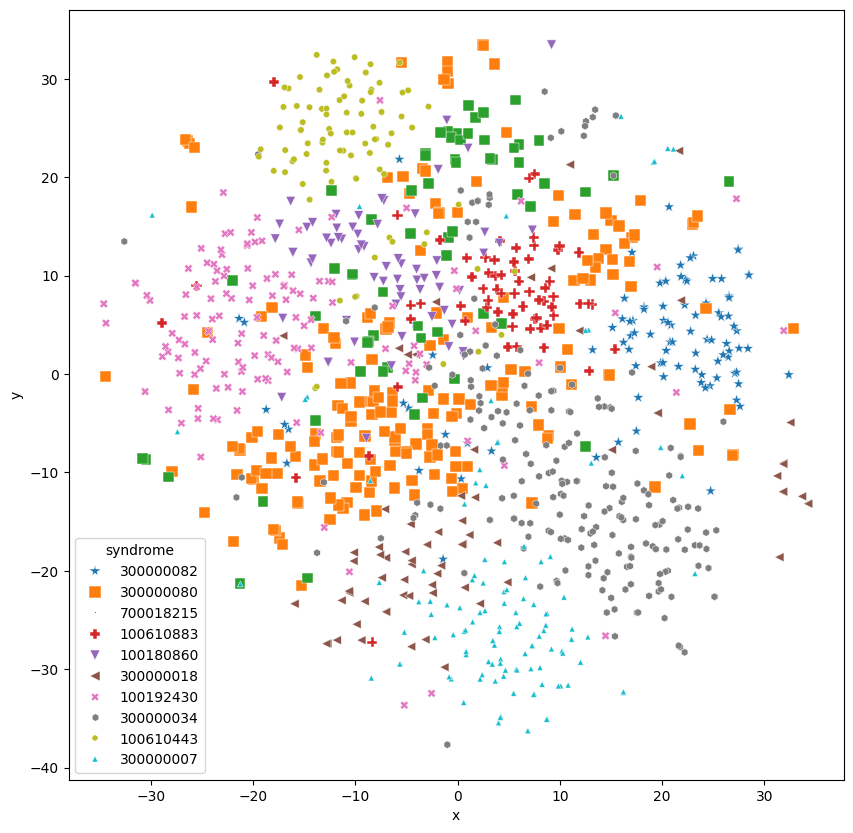

In [ ]:
plt.figure(figsize=(10,10))
sns.scatterplot(data=data_to_plot, x="x", y="y", hue="syndrome", markers=markers, style="syndrome", size="syndrome")
plt.show()

In [ ]:
for perplexity in [5, 10, 20, 30, 40, 50]:
  for learning_rate in [100, 200, 300, 500]:
    print(f"Testing perplexity={perplexity} learning-rate={learning_rate}")

    tsne_euclidean = TSNE(n_components=2, learning_rate=learning_rate, init='pca', perplexity=perplexity, n_jobs=4, metric="euclidean", random_state=42)
    tsne_cosine = TSNE(n_components=2, learning_rate=learning_rate, init='pca', perplexity=perplexity, n_jobs=4, metric="cosine", random_state=42)

    data_arr_norm = StandardScaler().fit_transform(data_arr)

    reduced_embbedding_euclidean = tsne_euclidean.fit_transform(data_arr_norm)
    reduced_embbedding_cosine = tsne_cosine.fit_transform(data_arr_norm)

    fig,ax = plt.subplots(1,2, figsize=(20,10))

    filename = f"plot-tsne-perplexity-{perplexity}-lr-{learning_rate}.png"

    data_to_plot_euclidean = pd.DataFrame(
        {
          "x":  reduced_embbedding_euclidean[:,0],
          "y":  reduced_embbedding_euclidean[:,1],
          "syndrome": mapping.syndrome.tolist(),
        },
        columns=("x", "y", "syndrome")
    )
    data_to_plot_cosine = pd.DataFrame(
        {
          "x":  reduced_embbedding_cosine[:,0],
          "y":  reduced_embbedding_cosine[:,1],
          "syndrome": mapping.syndrome.tolist(),
        },
        columns=("x", "y", "syndrome")
    )

    sns.scatterplot(data=data_to_plot_euclidean, x="x", y="y", hue="syndrome", markers=markers, style="syndrome", size="syndrome", ax=ax[0])
    sns.scatterplot(data=data_to_plot_cosine, x="x", y="y", hue="syndrome", markers=markers, style="syndrome", size="syndrome", ax=ax[1])

    ax[0].set_title(f"t-SNE euclidean perplexity={perplexity} learning_rate={learning_rate}")
    ax[1].set_title(f"t-SNE cosine perplexity={perplexity} learning_rate={learning_rate}")

    fig.savefig(os.path.join(plots_path, filename), bbox_inches="tight")
    plt.show()
    plt.close(fig)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
perplexities = []
divergence_scaler_1 = []
divergence_scaler_2 = []
divergence_scaler_3 = []

for perplexity in tqdm.tqdm(np.arange(5,55,5)):
  tsne_1 = TSNE(n_components=2, learning_rate="auto", init="pca", perplexity=perplexity, n_jobs=4, random_state=42, metric="cosine")
  tsne_2 = TSNE(n_components=2, learning_rate="auto", init="pca", perplexity=perplexity, n_jobs=4, random_state=42, metric="cosine")
  tsne_3 = TSNE(n_components=2, learning_rate="auto", init="pca", perplexity=perplexity, n_jobs=4, random_state=42, metric="cosine")

  data_arr_norm_1 = StandardScaler().fit_transform(data_arr)
  data_arr_norm_2 = normalize(data_arr, 'l2', axis=1)
  data_arr_norm_3 = normalize(data_arr, 'l1', axis=1)

  tsne_1.fit(data_arr_norm_1)
  tsne_2.fit(data_arr_norm_2)
  tsne_3.fit(data_arr_norm_3)


  perplexities.append(perplexity)
  divergence_scaler_1.append(tsne_1.kl_divergence_)
  divergence_scaler_2.append(tsne_2.kl_divergence_)
  divergence_scaler_3.append(tsne_3.kl_divergence_)

100%|██████████| 10/10 [02:44<00:00, 16.43s/it]


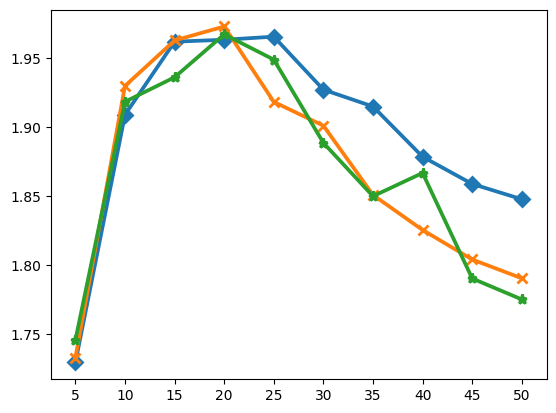

In [ ]:
sns.pointplot(x=perplexities, y=divergence_scaler_1, marker="D")
sns.pointplot(x=perplexities, y=divergence_scaler_2, marker="x")
sns.pointplot(x=perplexities, y=divergence_scaler_3, marker="*")
plt.show()


100%|██████████| 59/59 [02:00<00:00,  2.05s/it]


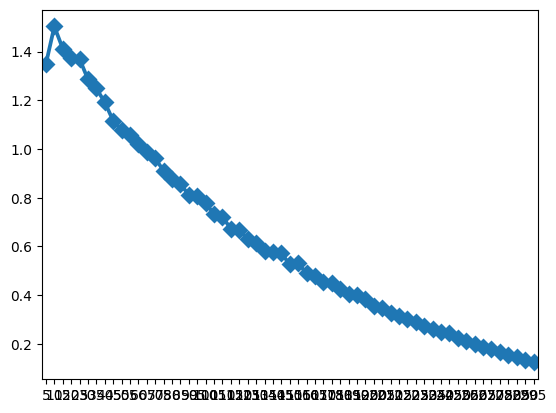

<Axes: xlabel='x', ylabel='y'>

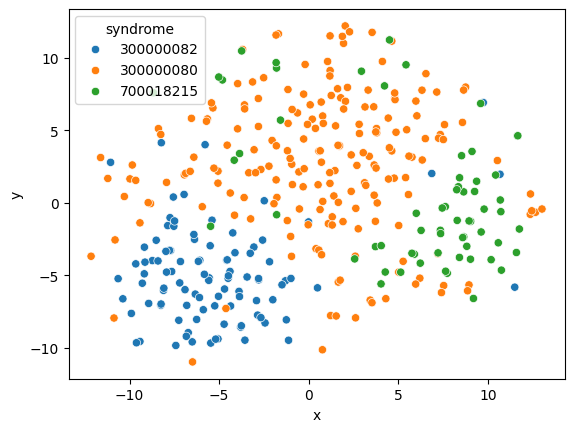

In [ ]:
syndromes = mapping.syndrome.unique()
syndrome = syndromes[2]

cut = mapping[mapping.syndrome == syndrome].index.tolist()[-1]
data = data_arr[:cut]

perplexities = []
divergence = []
for perplexity in tqdm.tqdm(np.arange(5,300,5)):
  tsne = TSNE(n_components=2, learning_rate="auto", init="pca", perplexity=perplexity, n_jobs=4, random_state=42)

  data_arr_norm = normalize(data, 'l2', axis=1)

  tsne.fit(data_arr_norm)

  perplexities.append(perplexity)
  divergence.append(tsne.kl_divergence_)

sns.pointplot(x=perplexities, y=divergence, marker="D")
plt.show()

tsne = TSNE(n_components=2, learning_rate="auto", init="pca", perplexity=50, n_jobs=4, random_state=42)
data_arr_norm = normalize(data, 'l2', axis=1)
test = tsne.fit_transform(data_arr_norm)

data_to_plot = pd.DataFrame(
        {
          "x":  test[:,0],
          "y":  test[:,1],
          "syndrome": mapping.syndrome.tolist()[:cut],
        },
        columns=("x", "y", "syndrome")
    )


sns.scatterplot(data=data_to_plot, x="x", y="y", hue="syndrome")

- [] test using exagerration
- [] plot how normalization and standardization acts
- [] use PCA before

0.24005337 0.29579607 -0.2581644 -0.21428157
2.3364277 2.9230006 -2.5724835 -2.1009135


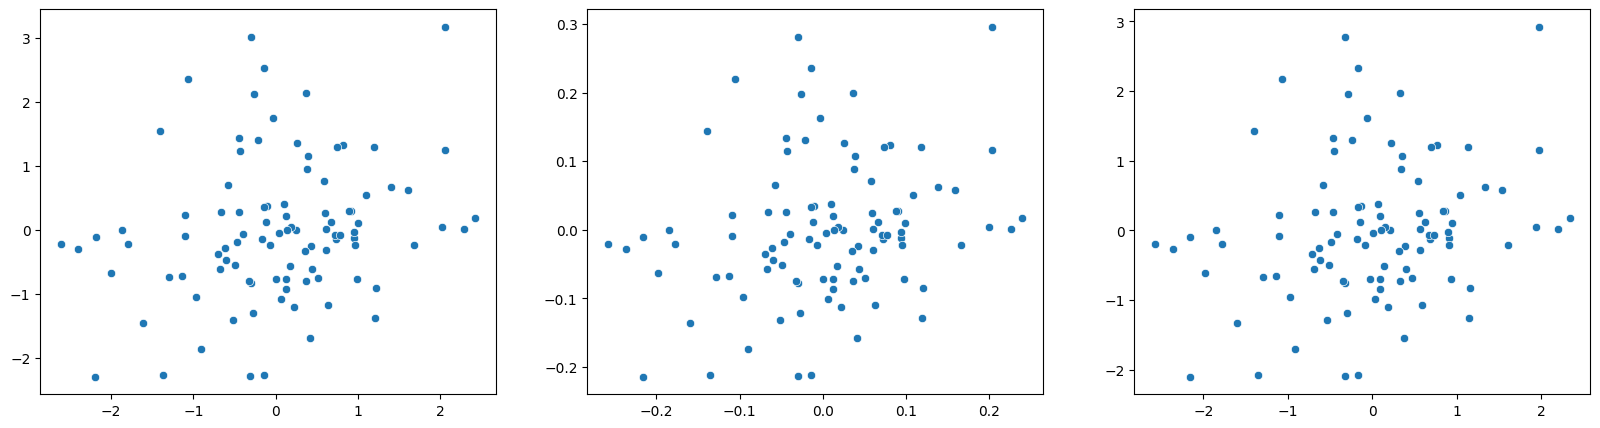

In [ ]:
# testing normalization and standardization

syndromes = mapping.syndrome.unique()
syndrome = syndromes[0]
cut = mapping[mapping.syndrome == syndrome].index.tolist()[-1]

data = data_arr[:cut]
normalized = normalize(data, 'l2', axis=0)
standardized = StandardScaler().fit_transform(data)

fig,ax = plt.subplots(1,3,figsize=(20,5))
sns.scatterplot(ax=ax[0], x=data[:,0], y=data[:,1])
sns.scatterplot(ax=ax[1], x=normalized[:,0], y=normalized[:,1])
sns.scatterplot(ax=ax[2], x=standardized[:,0], y=standardized[:,1])

print(max(normalized[:,0]), max(normalized[:,1]), min(normalized[:,0]), min(normalized[:,1]))
print(max(standardized[:,0]), max(standardized[:,1]), min(standardized[:,0]), min(standardized[:,1]))


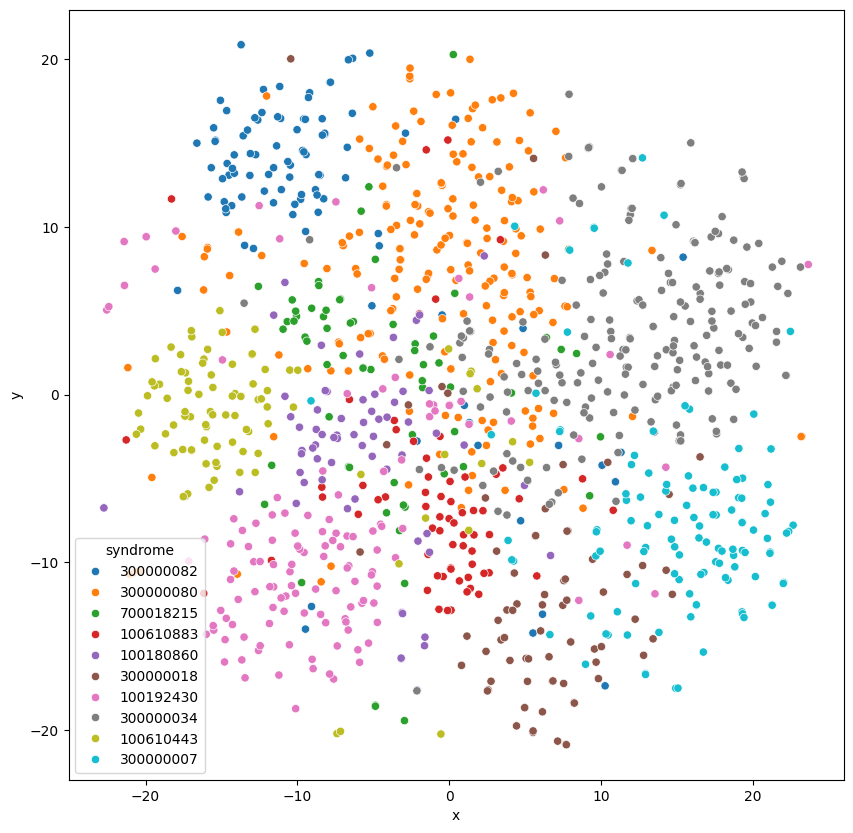

In [ ]:
# testing exageration
tsne = TSNE(n_components=2, learning_rate='auto', init='pca', perplexity=50, n_jobs=4, early_exaggeration=4)
data_arr_norm = normalize(data_arr, 'l2', axis=0)
reduced_embbedding = tsne.fit_transform(data_arr_norm)

data_to_plot = pd.DataFrame(
    {
      "x":  reduced_embbedding[:,0],
      "y":  reduced_embbedding[:,1],
      "syndrome": mapping.syndrome.tolist(),
    },
    columns=("x", "y", "syndrome")
)
plt.figure(figsize=(10,10))
sns.scatterplot(data=data_to_plot, x="x", y="y", hue="syndrome")
plt.show()


(1116, 20)


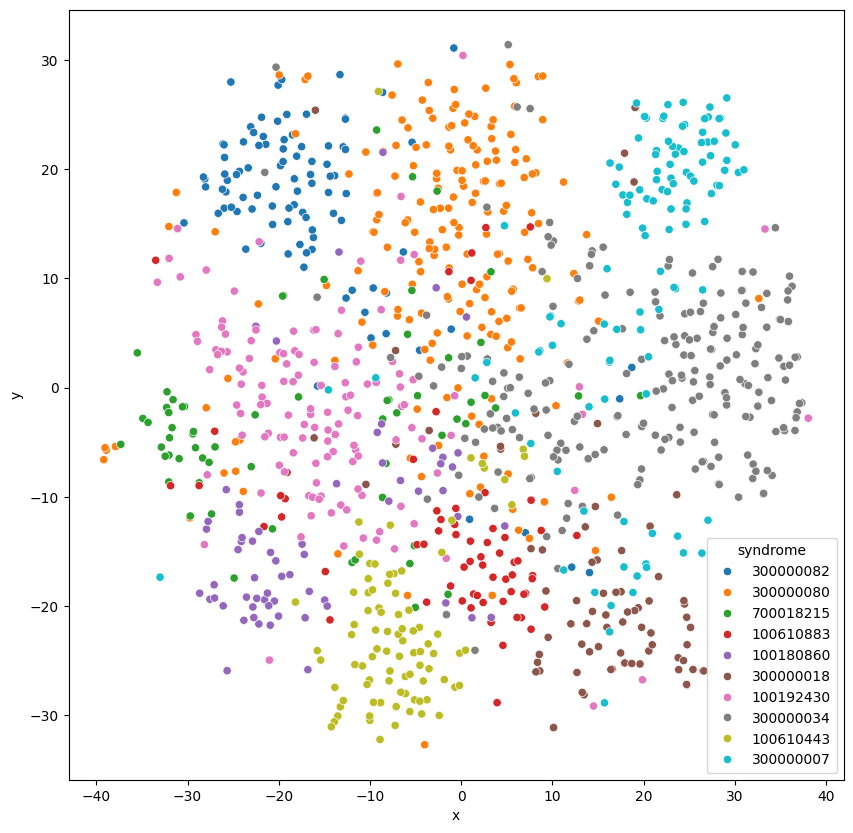

In [ ]:
pca = PCA(n_components=20, random_state=42)
tsne = TSNE(n_components=2, learning_rate='auto', init='random', n_jobs=4, random_state=42)
data_arr_norm = normalize(data_arr, 'l2', axis=0)
x_pca = pca.fit_transform(data_arr_norm)
print(x_pca.shape)
reduced_embbedding = tsne.fit_transform(x_pca)

data_to_plot = pd.DataFrame(
    {
      "x":  reduced_embbedding[:,0],
      "y":  reduced_embbedding[:,1],
      "syndrome": mapping.syndrome.tolist(),
    },
    columns=("x", "y", "syndrome")
)
plt.figure(figsize=(10,10))
sns.scatterplot(data=data_to_plot, x="x", y="y", hue="syndrome")
plt.show()

In [ ]:
tsne = TSNE(n_components=2, init='pca', n_jobs=4, random_state=42)
data_arr_norm = normalize(data_arr, 'l2', axis=0)
reduced_embbedding = tsne.fit_transform(data_arr_norm)

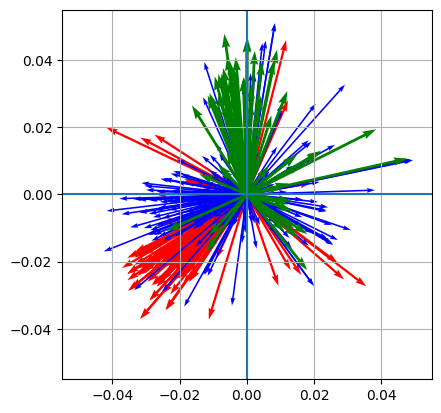

In [ ]:
syndromes = mapping.syndrome.unique()
syndrome = syndromes[0]

first_cut = mapping[mapping.syndrome == syndromes[0]].index.tolist()[-1]
second_cut = mapping[mapping.syndrome == syndromes[1]].index.tolist()[-1]
third_cut = mapping[mapping.syndrome == syndromes[2]].index.tolist()[-1]

u1 = reduced_embbedding[:first_cut,0]
v1 = reduced_embbedding[:first_cut,1]

u2 = reduced_embbedding[first_cut:second_cut,0]
v2 = reduced_embbedding[first_cut:second_cut,1]

u3 = reduced_embbedding[second_cut:third_cut,0]
v3 = reduced_embbedding[second_cut:third_cut,1]

plt.quiver(np.zeros(len(u1)),np.zeros(len(v1)),u1,v1,angles='xy', scale_units='xy', scale=700, color="red")
plt.quiver(np.zeros(len(u2)),np.zeros(len(v2)),u2,v2,angles='xy', scale_units='xy', scale=700, color="blue")
plt.quiver(np.zeros(len(u3)),np.zeros(len(v3)),u3,v3,angles='xy', scale_units='xy', scale=700, color="green")
plt.axhline(0)
plt.axvline(0)
plt.grid()
plt.gca().set_aspect('equal', adjustable='box')
plt.show()

In [ ]:
tsne = TSNE(n_components=3, init='pca', n_jobs=4, random_state=42)
data_arr_norm = normalize(data_arr, 'l2', axis=0)
reduced_embbedding = tsne.fit_transform(data_arr_norm)

In [ ]:
reduced_embbedding

array([[-17.765522 ,  24.245499 ,   2.0396914],
       [ 42.37717  ,   5.947611 ,  -5.3687925],
       [  4.388622 ,  13.9738245,   4.66547  ],
       ...,
       [  5.9135885, -27.62336  , -23.116634 ],
       [ 27.00141  ,   7.327643 ,  22.904755 ],
       [  0.9399297,  24.42428  , -28.728035 ]], dtype=float32)

In [ ]:
import plotly.graph_objects as go

first_cut = mapping[mapping.syndrome == syndromes[0]].index.tolist()[-1]

u1 = reduced_embbedding[:first_cut,0]
v1 = reduced_embbedding[:first_cut,1]
w1 = reduced_embbedding[:first_cut,2]

x1 = np.zeros(len(u1))
y1 = np.zeros(len(v1))
z1 = np.zeros(len(w1))

fig = go.Figure(data=go.Cone(
    x=x1,
    y=y1,
    z=z1,
    u=u1,
    v=v1,
    w=w1,
    sizemode="scaled",
    sizeref=1
))

fig.show()

100%|██████████| 10/10 [04:32<00:00, 27.26s/it]


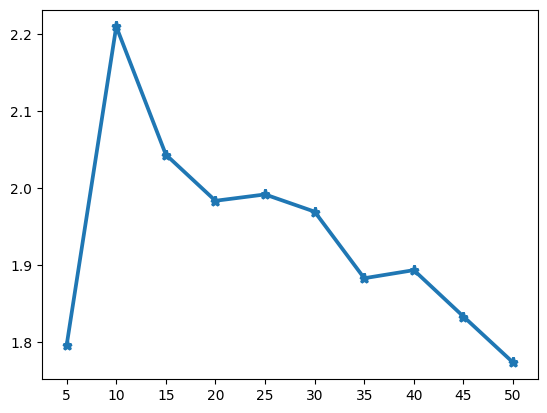

In [ ]:
perplexities = []
divergence = []

for perplexity in tqdm.tqdm(np.arange(5,55,5)):
  tsne_1 = TSNE(n_components=2, learning_rate=700, init="pca", perplexity=perplexity, n_jobs=4, random_state=42, max_iter=6000)

  data_arr_norm = normalize(data_arr, 'l2', axis=1)

  tsne_1.fit(data_arr_norm)

  perplexities.append(perplexity)
  divergence.append(tsne_1.kl_divergence_)
sns.pointplot(x=perplexities, y=divergence, marker="*")
plt.show()

In [ ]:
import umap

(1116, 2)


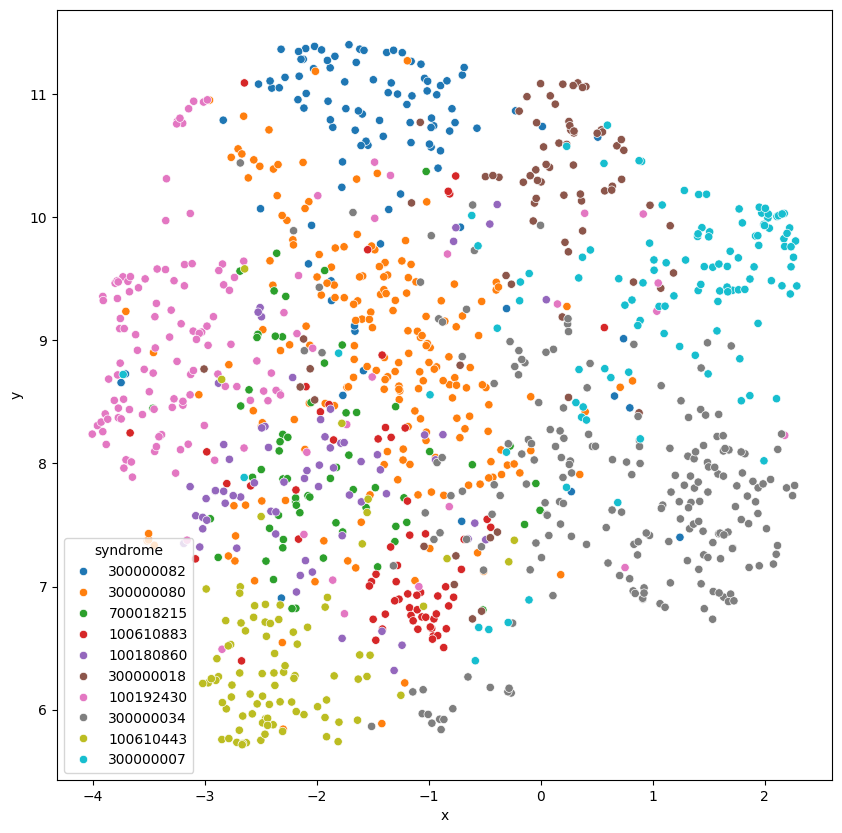

In [ ]:
u = umap.UMAP(n_components=2, n_neighbors=10)
data_arr_norm = normalize(data_arr, 'l2', axis=0)
u_output = u.fit_transform(data_arr_norm)
print(u_output.shape)

data_to_plot = pd.DataFrame(
    {
      "x":  u_output[:,0],
      "y":  u_output[:,1],
      "syndrome": mapping.syndrome.tolist(),
    },
    columns=("x", "y", "syndrome")
)
plt.figure(figsize=(10,10))
sns.scatterplot(data=data_to_plot, x="x", y="y", hue="syndrome")
plt.show()

(1116, 2)


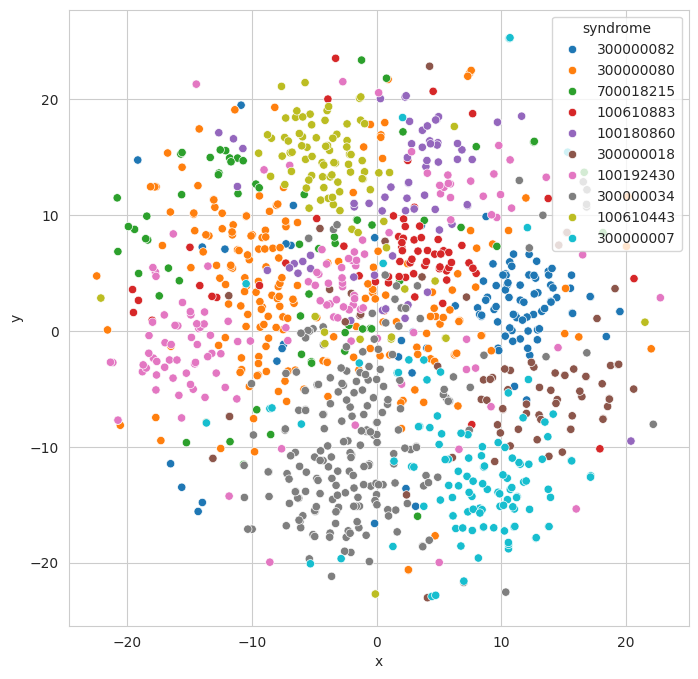

In [9]:
u = TSNE(n_components=2, random_state=42, perplexity=50, learning_rate=800)
data_arr_norm = normalize(data_arr, 'l2', axis=0)
u_output = u.fit_transform(data_arr_norm)
print(u_output.shape)

data_to_plot = pd.DataFrame(
    {
      "x":  u_output[:,0],
      "y":  u_output[:,1],
      "syndrome": mapping.syndrome.tolist(),
    },
    columns=("x", "y", "syndrome")
)


NameError: name 'plots_path' is not defined

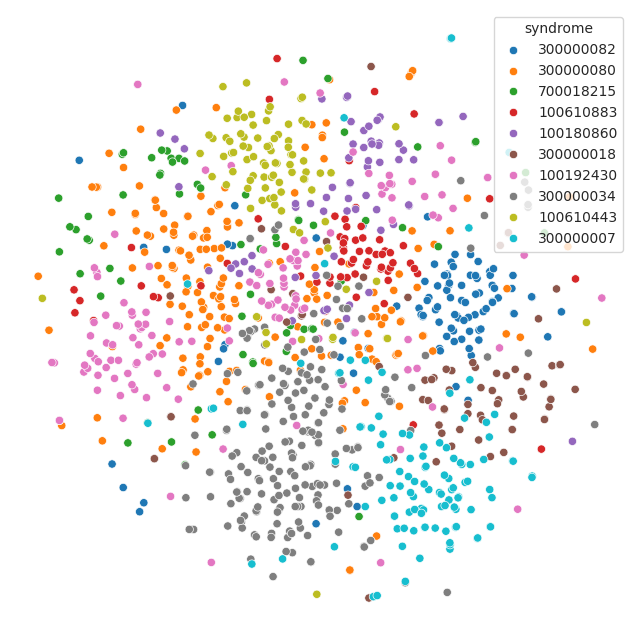

In [12]:
sns.set_style("whitegrid")

plt.figure(figsize=(8,8))
sns.scatterplot(data=data_to_plot, x="x", y="y", hue="syndrome")
plt.axis('off')
plt.savefig(os.path.join(plots_path, "tsne.png"), bbox_inches="tight")
plt.show()